# Generación y comparación de atribuciones con XAI-metrics

Este notebook adapta el flujo de `prueba/main.py` a un ejemplo pequeño y reproducible. A partir de un mismo modelo **Isolation Forest**:

1. Genera atribuciones locales con **LIME** y **SHAP**.
2. Evalúa ambos métodos con las métricas `Complexity` y `Sparseness`.
3. Construye un reporte final que permite compararlos.






## 1. Preparar el entorno

El paquete debe estar instalado en modo editable con `pip install -e .`. También añadimos `prueba/` al path para reutilizar las funciones de generación de atribuciones y cargar el modelo de ejemplo.

In [1]:
import sys
from pathlib import Path

import cloudpickle
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import shap
import torch
from IPython.display import display
from lime.lime_tabular import LimeTabularExplainer
from typing import List

ROOT = Path.cwd()
if not (ROOT / "xai_metrics").exists():
    ROOT = ROOT.parent

sys.path.insert(0, str(ROOT))
sys.path.insert(0, str(ROOT / "prueba"))

from xai_metrics.base import MetricContext
from xai_metrics.reporting import build_reports
from xai_metrics.runner import run_evaluation

## 2. Definir los métodos de atribución

Para que el ejemplo sea autocontenido, definimos aquí las funciones locales `usar_lime` y `usar_shap_local`. Ambas devuelven una matriz con una fila por observación y una columna por variable.

In [2]:
def _make_lime_explainer(X_train: pd.DataFrame):
    cols = list(X_train.columns)

    explainer = LimeTabularExplainer(
        X_train.values,
        feature_names=cols,
        mode="classification",
        random_state=42
    )

    return explainer, cols


def _lime_attributions(
    model,
    explainer: LimeTabularExplainer,
    X: pd.DataFrame,
    cols: List[str]
):
    X_np = np.asarray(X)
    attributions = []

    for row in X_np:
        explanation = explainer.explain_instance(
            data_row=row,
            predict_fn=model.predict_proba,
            num_features=len(cols)
        )

        pesos = np.zeros(len(cols))
        for feature_idx, weight in explanation.as_map()[1]:
            pesos[feature_idx] = float(weight)

        attributions.append(pesos)

    return np.asarray(attributions)


def make_lime_explain_func(X_train: pd.DataFrame):
    explainer, cols = _make_lime_explainer(X_train)

    def explain_func(model, inputs, targets=None, **kwargs):
        if hasattr(model, "predict_proba"):
            pyod_model = model
        elif hasattr(model, "model") and hasattr(model.model, "predict_proba"):
            pyod_model = model.model
        else:
            raise AttributeError(
                f"No se encontró predict_proba en {type(model)} ni en model.model"
            )

        return _lime_attributions(
            model=pyod_model,
            explainer=explainer,
            X=inputs,
            cols=cols
        )
    
    return explain_func

In [3]:
def _shap_attributions(
    model,
    X_train: pd.DataFrame,
    X_test: pd.DataFrame
):
    def f(X):
        if hasattr(model, "decision_function"):
            return model.decision_function(X)
        return model

    # Importancia de la variable en el score de anomalia
    explainer = shap.Explainer(f, X_train)
    shap_values = explainer(X_test)

    return np.abs(shap_values.values)


def make_shap_local_explain_func(X_train: pd.DataFrame):
    def explain_func(model, inputs, targets=None, **kwargs):
        if isinstance(inputs, torch.Tensor):
            X_np = inputs.detach().cpu().numpy()
        else:
            X_np = np.asarray(inputs)

        if X_np.ndim == 1:
            X_np = X_np.reshape(1, -1)

        X_batch = pd.DataFrame(X_np, columns=X_train.columns)

        if hasattr(model, "decision_function"):
            pyod_model = model
        elif hasattr(model, "model") and hasattr(model.model, "decision_function"):
            pyod_model = model.model
        else:
            raise AttributeError(
                f"No se encontró decision_function en {type(model)} ni en model.model"
            )

        return _shap_attributions(
            model=pyod_model,
            X_train=X_train,
            X_test=X_batch
        )
    
    return explain_func

## 3. Cargar el modelo y los datos

El modelo guardado contiene un wrapper compatible con las métricas de la librería. Para generar las atribuciones, LIME y SHAP utilizan el modelo PyOD original disponible en `wrapped_model.model`.

In [4]:
X_train = pd.read_csv(ROOT / "prueba/data/hydraulic/X_train_norm.csv", index_col=0)
X_test = pd.read_csv(ROOT / "prueba/data/hydraulic/X_test_train_norm.csv", index_col=0)
y_test = pd.read_csv(ROOT / "prueba/data/hydraulic/y_test_train.csv", index_col=0).iloc[:, 0]

model_path = ROOT / "prueba/results/models/hydraulic/AutoEncoder/hydraulic_AutoEncoder_seed_0.pkl"
with model_path.open("rb") as model_file:
    wrapped_model = cloudpickle.load(model_file)

observations = [9, 5, 249, 252, 255, 685, 403, 420]
X_observations = X_test.loc[observations]

print(f"Datos de entrenamiento: {X_train.shape}")
print(f"Observaciones que se explicarán: {observations}")
X_observations

Datos de entrenamiento: (1323, 6)
Observaciones que se explicarán: [9, 5, 249, 252, 255, 685, 403, 420]


,PS1,PS3,PS4,PS5,EPS1,VS1
9,0.158491,0.845890,0.000000,0.458254,0.316514,0.150355
5,0.177378,0.906931,0.000000,0.579992,0.371375,0.153532
249,0.037596,0.705267,0.000003,0.093639,0.144549,0.439519
252,0.044655,0.714562,0.000000,0.089974,0.111587,0.425114
255,0.047678,0.713065,0.000000,0.092376,0.116156,0.422890
685,0.684246,0.234101,0.000000,0.024249,0.648441,0.617731
403,0.017701,0.712482,0.018254,0.040247,0.075315,0.411556
420,0.009033,0.716993,0.000000,0.040070,0.067106,0.379091


## 4. Generar atribuciones LIME y SHAP

Los dos métodos explican exactamente las mismas observaciones. Se usa una muestra reproducible de 100 filas como conjunto de referencia para acelerar el ejemplo.

In [5]:
X_background = X_train.sample(n=100, random_state=42)
pyod_model = wrapped_model.model

lime_values = usar_lime(
    clf=pyod_model,
    X_train=X_background,
    X_test=X_test,
    observaciones=observations,
)

shap_values = usar_shap_local(
    clf=pyod_model,
    X_train=X_background,
    X_test=X_test,
    observaciones=observations,
)

lime_attributions = pd.DataFrame(lime_values, index=observations, columns=X_test.columns)
shap_attributions = pd.DataFrame(shap_values, index=observations, columns=X_test.columns)

lime_attributions.index.name = "observation"
shap_attributions.index.name = "observation"

print("Atribuciones LIME")
display(lime_attributions)
print("Atribuciones SHAP")
display(shap_attributions)

NameError: name 'usar_lime' is not defined

## 5. Comparar visualmente las atribuciones

La siguiente gráfica compara la importancia absoluta media de cada variable. Esta comparación describe las atribuciones; la evaluación cuantitativa con XAI-metrics se realiza en el siguiente paso.

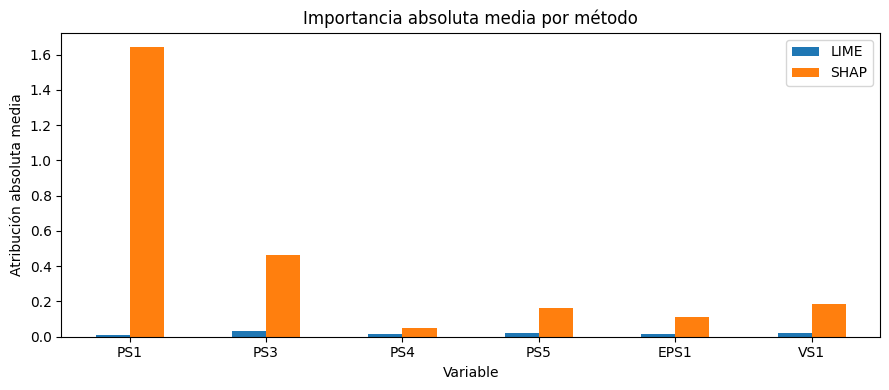

In [6]:
mean_absolute_attributions = pd.DataFrame({
    "LIME": lime_attributions.abs().mean(),
    "SHAP": shap_attributions.abs().mean(),
})

ax = mean_absolute_attributions.plot.bar(figsize=(9, 4))
ax.set_title("Importancia absoluta media por método")
ax.set_xlabel("Variable")
ax.set_ylabel("Atribución absoluta media")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## 6. Evaluar ambos métodos con XAI-metrics

Cada matriz de atribuciones se introduce en un `MetricContext`. Ambos contextos comparten modelo, datos, etiquetas y observaciones, por lo que la comparación se realiza en las mismas condiciones.

- `Complexity`: valores menores indican explicaciones menos complejas.
- `Sparseness`: valores mayores indican explicaciones más concentradas en pocas variables.

In [7]:
# metrics_config = {
#     "metrics": [
#         {"name": "Complexity", "params": {"normalise": True}},
#         {"name": "Sparseness", "params": {"normalise": True}},
#     ]
# }

X_train = pd.read_csv("data/hydraulic/X_test.csv", index_col=[0])

explain_funcs = {
    "LIME": make_lime_explain_func(X_train),
    "SHAP": make_shap_local_explain_func(X_train)
}


def evaluate_attributions(method_name, attributions):
    # context = MetricContext(
    #     model=wrapped_model,
    #     X_test=X_test,
    #     y_test=y_test,
    #     observations=observations,
    #     attributions=attributions.to_numpy(),
    #     device="cpu",
    # )

    return run_evaluation(
        config="config_example.yaml",
        report_output_dir=None,
    )


# lime_results = evaluate_attributions("LIME", lime_attributions)
# shap_results = evaluate_attributions("SHAP", shap_attributions)

run_evaluation(
    config="config_example.yaml",
    report_output_dir=None,
    explain_funcs=explain_funcs
)

Evaluating dataset hydraulic, model IForest and XAI method LIME
Evaluating dataset hydraulic, model IForest and XAI method SHAP


{'contexts': [{'metadata': {'dataset_name': 'hydraulic',
    'model_name': 'IForest',
    'xai_method_name': 'LIME'},
   'results': {'Complexity': [np.float64(1.1651165484771915),
     np.float64(0.8615800693120479),
     np.float64(1.3783726321694083),
     np.float64(1.1369552015690296),
     np.float64(1.2074305673320815),
     np.float64(1.5088303119656892),
     np.float64(1.37403277330477),
     np.float64(1.1173721664047336)],
    'Sparseness': [np.float64(0.5498676385672403),
     np.float64(0.6828919859440418),
     np.float64(0.44706838433838075),
     np.float64(0.5800231893462668),
     np.float64(0.5622077455016828),
     np.float64(0.3803970424909388),
     np.float64(0.4515311546907894),
     np.float64(0.6058591016973194)],
    'Faithfulness': [-0.8789326059735124,
     0.812850251173681,
     0.28150970713229073,
     -0.9336222087375396,
     -0.9281563924452132,
     -0.9244381316768671,
     -0.3240513678386932,
     -0.9561862910852434],
    'LocalLipschitzEstimate

## 7. Reporte comparativo final

`build_reports` combina los resultados de ambos contextos. Las filas son métricas y las columnas son los métodos XAI comparados.

In [4]:
combined_reports = build_reports(
    lime_results["contexts"] + shap_results["contexts"]
)

comparison = combined_reports["hydraulic"]["IForest"]
comparison

NameError: name 'lime_results' is not defined

In [ ]:
ax = comparison.plot.bar(figsize=(8, 4))
ax.set_title("Comparación de métricas XAI")
ax.set_xlabel("Métrica")
ax.set_ylabel("Valor medio")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

Para evaluar otras métricas, basta con añadirlas a `metrics_config`. Algunas métricas de robustez o fidelidad también necesitan recibir una función capaz de regenerar explicaciones durante la evaluación.